<a href="https://colab.research.google.com/github/souzaalliane-svg/Projeto-da-Visualiza-o-da-Informa-o_-Alliane-Souza/blob/main/Projeto_da_Visualiza%C3%A7%C3%A3o_da_Informa%C3%A7%C3%A3o__Alliane_Souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#Nome: Alliane Souza da Silva Cipriano
#RGM: 04409383-7
#Instituição: Unicid
#Curso: Ciência da Computação
#Projeto da Visualização da Informação - USD/BRL

In [1]:
!pip install pdfplumber -q

import pdfplumber
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 66.5 MB/s eta 0:00:00


In [9]:
caminho_pdf = "USD_BRL_hist 5.pdf"

print("Extraindo dados do PDF...")
todas = []
with pdfplumber.open(caminho_pdf) as pdf:
    for pagina in pdf.pages:
        texto = pagina.extract_text()
        pares = re.findall(r'(\d{2}\.\d{2}\.\d{4}),([\d\.]+)', texto)
        for data_str, cotacao_str in pares:
            data_obj = datetime.strptime(data_str, "%d.%m.%Y")
            cotacao = float(cotacao_str)
            todas.append([data_obj, cotacao])

df = pd.DataFrame(todas, columns=["data", "cotacao"])
df = df.sort_values("data").reset_index(drop=True)
print(f"Carregado: {len(df)} dias, de {df['data'].min().date()} a {df['data'].max().date()}")


Extraindo dados do PDF...
Carregado: 2608 dias, de 2010-01-01 a 2019-12-31


In [11]:
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["mes_nome"] = df["data"].dt.strftime("%b")

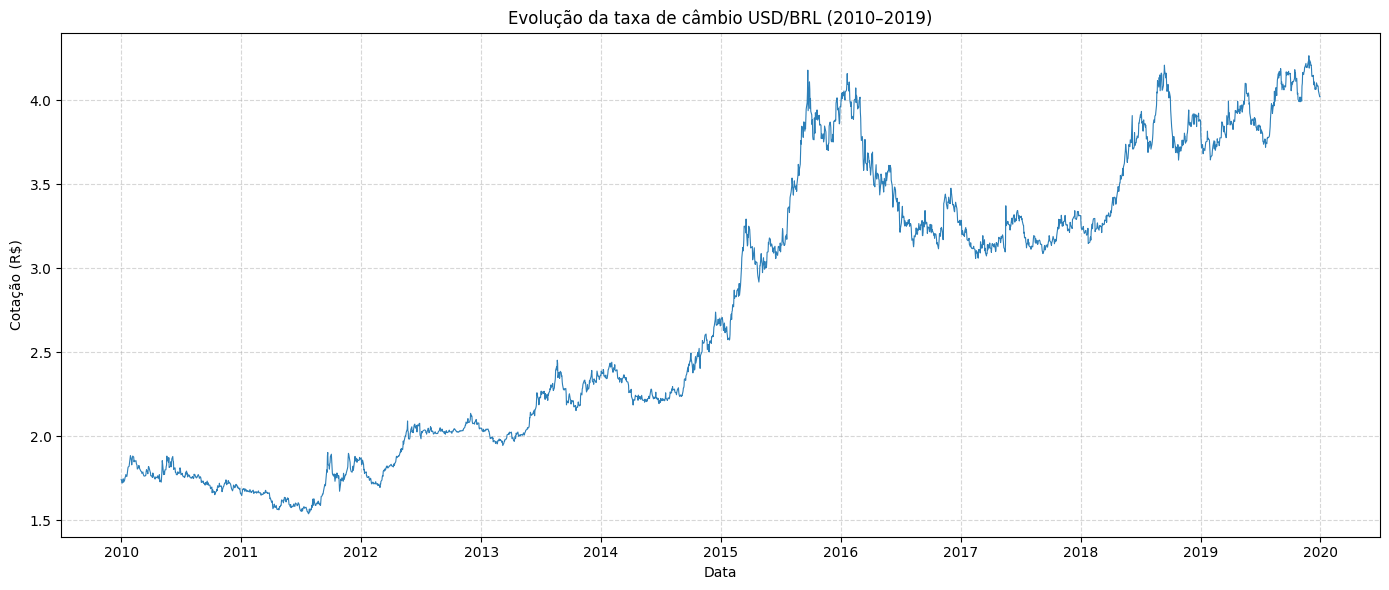

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df["data"], df["cotacao"], color="#2c7fb8", linewidth=0.8)
plt.title("Evolução da taxa de câmbio USD/BRL (2010–2019)")
plt.xlabel("Data")
plt.ylabel("Cotação (R$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_651/1620561957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medias_ano, x="ano", y="cotacao", palette="viridis")


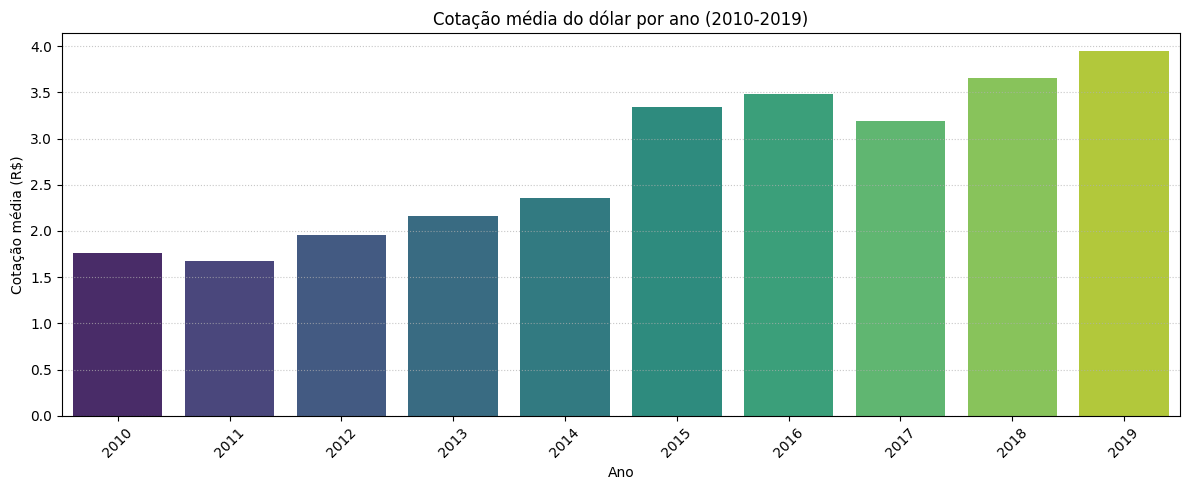

In [13]:
medias_ano = df.groupby("ano")["cotacao"].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(data=medias_ano, x="ano", y="cotacao", palette="viridis")
plt.title("Cotação média do dólar por ano (2010-2019)")
plt.xlabel("Ano")
plt.ylabel("Cotação média (R$)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
hierarquia = df.groupby(["ano", "mes", "mes_nome"])["cotacao"].mean().reset_index()
hierarquia = hierarquia.sort_values(["ano", "mes"])
hierarquia["label"] = hierarquia["mes_nome"] + " - R$ " + hierarquia["cotacao"].round(2).astype(str)

fig = px.treemap(
    hierarquia,
    path=["ano", "label"],
    values="cotacao",
    color="cotacao",
    color_continuous_scale="RdBu",
    title="Treemap: média mensal do dólar por ano (2010-2019)"
)
fig.update_traces(textinfo="label+value", textfont_size=12)
fig.show()